# 04 - Model evaluation and champion selection

**Task.** Compare the three retrieval representations using the same 1% job catalog and 100 resume queries, then identify what evidence is still required for champion selection.

The three methods are unigram TF-IDF, unigram-plus-bigram TF-IDF, and MiniLM transformer embeddings. Runtime and top-K overlap describe computational cost and model disagreement; they do **not** establish recommendation quality. Quality requires blinded relevance judgments.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'final_project' else Path.cwd().resolve()

def read_json(path):
    path = Path(path)
    return json.loads(path.read_text(encoding='utf-8')) if path.exists() else None

ngram_metrics = read_json(
    PROJECT_ROOT / 'data/gold/benchmarks/ngram_1pct_validation/metrics.json'
)
transformer_validation_path = (
    PROJECT_ROOT / 'data/gold/benchmarks/transformer_1pct_validation/metrics.json'
)
transformer_legacy_path = (
    PROJECT_ROOT / 'data/gold/benchmarks/transformer_1pct/metrics.json'
)
transformer_metrics = read_json(transformer_validation_path)
transformer_status = 'validation' if transformer_metrics else 'legacy pre-split'
if transformer_metrics is None:
    transformer_metrics = read_json(transformer_legacy_path)

if ngram_metrics is None:
    raise FileNotFoundError('Run jobapps.pipelines.ngram_benchmark first.')
if transformer_metrics is None:
    raise FileNotFoundError('Run jobapps.pipelines.transformer_benchmark first.')

print(f"Transformer evidence loaded: {transformer_status}")

Transformer evidence loaded: validation


## Three-method summary

All rows use the same 13,634 sampled jobs and the exact same 100 validation resume IDs. This makes every pairwise retrieval comparison valid.

In [2]:
comparison = pd.DataFrame([
    {
        'method': 'Unigram TF-IDF',
        'representation': 'Single normalized terms',
        'execution': 'Spark ML',
        'measured_seconds': ngram_metrics['unigram_seconds'],
        'top10_overlap_with_unigram': 1.0,
        'query_evidence': ngram_metrics['resume_query_split'],
    },
    {
        'method': 'Unigram + bigram TF-IDF',
        'representation': 'Terms and adjacent phrases',
        'execution': 'Spark ML',
        'measured_seconds': ngram_metrics['ngram_seconds'],
        'top10_overlap_with_unigram': ngram_metrics['mean_top_k_overlap'],
        'query_evidence': ngram_metrics['resume_query_split'],
    },
    {
        'method': 'MiniLM transformer',
        'representation': '384-dimensional semantic vectors',
        'execution': 'PyTorch inference; Spark I/O/evaluation',
        'measured_seconds': transformer_metrics['embedding_seconds'],
        'top10_overlap_with_unigram': transformer_metrics['mean_top_k_overlap'],
        'query_evidence': transformer_status,
    },
])
comparison['top10_changed_vs_unigram'] = 1 - comparison['top10_overlap_with_unigram']
comparison.style.format({
    'measured_seconds': '{:,.1f}',
    'top10_overlap_with_unigram': '{:.1%}',
    'top10_changed_vs_unigram': '{:.1%}',
})

,method,representation,execution,measured_seconds,top10_overlap_with_unigram,query_evidence,top10_changed_vs_unigram
0,Unigram TF-IDF,Single normalized terms,Spark ML,16.4,100.0%,validation,0.0%
1,Unigram + bigram TF-IDF,Terms and adjacent phrases,Spark ML,32.8,73.1%,validation,26.9%
2,MiniLM transformer,384-dimensional semantic vectors,PyTorch inference; Spark I/O/evaluation,709.6,40.4%,validation,59.6%


The runtime column measures representation construction plus exact retrieval for the two lexical benchmark branches, but transformer encoding only for MiniLM. Transformer exact retrieval took an additional 2.7 seconds in the retained run. The values therefore support an engineering-cost comparison, not a perfectly isolated microbenchmark.

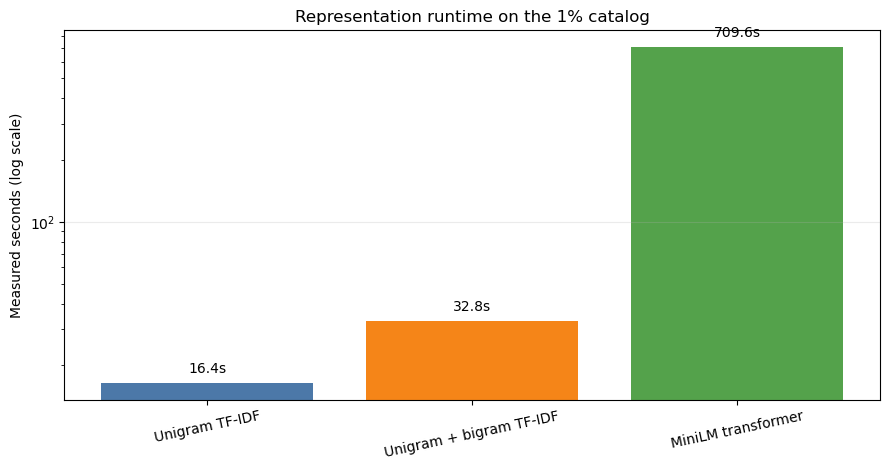

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.8))
colors = ['#4C78A8', '#F58518', '#54A24B']
bars = ax.bar(comparison['method'], comparison['measured_seconds'], color=colors)
ax.set_yscale('log')
ax.set_ylabel('Measured seconds (log scale)')
ax.set_title('Representation runtime on the 1% catalog')
ax.grid(axis='y', alpha=0.25)
ax.tick_params(axis='x', rotation=12)
for bar, value in zip(bars, comparison['measured_seconds']):
    ax.text(bar.get_x() + bar.get_width() / 2, value * 1.12, f'{value:,.1f}s', ha='center')
plt.tight_layout()
plt.show()

## How differently do the methods retrieve?

The heatmap reports all three pairwise top-10 overlaps on identical validation queries. Larger overlap means two representations return more of the same jobs; it does not mean either representation is more relevant.

,Unigram,N-gram,Transformer
Unigram,100.0%,73.1%,40.4%
N-gram,73.1%,100.0%,39.7%
Transformer,40.4%,39.7%,100.0%


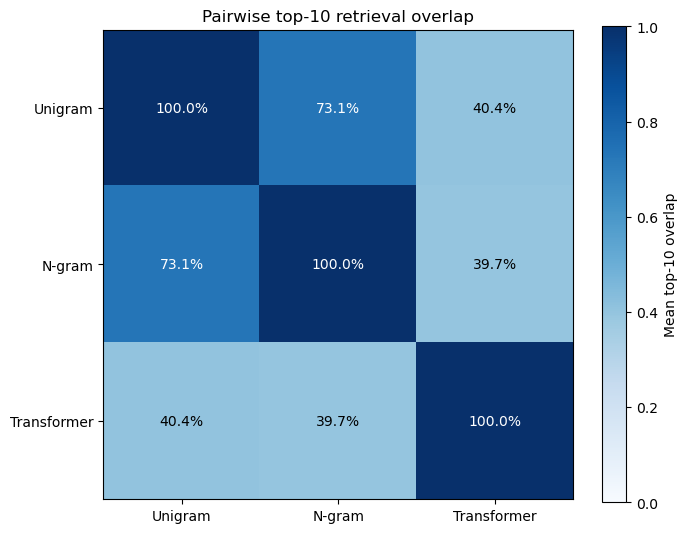

In [4]:
top_k_root = PROJECT_ROOT / 'data/gold/benchmarks'
top_k = {
    'Unigram': pd.read_parquet(top_k_root / 'ngram_1pct_validation/unigram_top_k'),
    'N-gram': pd.read_parquet(top_k_root / 'ngram_1pct_validation/ngram_top_k'),
    'Transformer': pd.read_parquet(top_k_root / 'transformer_1pct_validation/transformer_top_k'),
}
query_ids = {name: set(frame['resume_id']) for name, frame in top_k.items()}
if not (query_ids['Unigram'] == query_ids['N-gram'] == query_ids['Transformer']):
    raise ValueError('Pairwise overlap requires identical resume query IDs.')

def mean_pairwise_overlap(left, right, k=10):
    left_sets = left.groupby('resume_id')['job_link'].agg(set)
    right_sets = right.groupby('resume_id')['job_link'].agg(set)
    return sum(len(left_sets[query] & right_sets[query]) / k for query in left_sets.index) / len(left_sets)

labels = list(top_k)
overlap_matrix = pd.DataFrame(np.eye(len(labels)), index=labels, columns=labels)
for row_index, left_name in enumerate(labels):
    for column_index, right_name in enumerate(labels):
        if row_index < column_index:
            overlap = mean_pairwise_overlap(top_k[left_name], top_k[right_name])
            overlap_matrix.loc[left_name, right_name] = overlap
            overlap_matrix.loc[right_name, left_name] = overlap

display(overlap_matrix.style.format('{:.1%}').background_gradient(cmap='Blues', vmin=0, vmax=1))
fig, ax = plt.subplots(figsize=(7, 5.5))
image = ax.imshow(overlap_matrix.values, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels=labels)
ax.set_yticks(range(len(labels)), labels=labels)
ax.set_title('Pairwise top-10 retrieval overlap')
for row_index in range(len(labels)):
    for column_index in range(len(labels)):
        value = overlap_matrix.iloc[row_index, column_index]
        ax.text(column_index, row_index, f'{value:.1%}', ha='center', va='center', color='white' if value > 0.55 else 'black')
fig.colorbar(image, ax=ax, label='Mean top-10 overlap')
plt.tight_layout()
plt.show()

## Capability and evidence table

This qualitative table prevents runtime or disagreement from being mistaken for relevance performance.

In [5]:
capabilities = pd.DataFrame([
    ['Unigram TF-IDF', 'Exact word overlap', 'No', 'Fastest benchmark', 'Validation'],
    ['Unigram + bigram TF-IDF', 'Word overlap plus adjacent phrases', 'Limited', '2.0x unigram runtime', 'Validation'],
    ['MiniLM transformer', 'Semantic similarity', 'Yes', 'Much higher encoding cost', transformer_status],
], columns=['method', 'matching signal', 'adjacent language', 'observed cost', 'evidence status'])
capabilities

,method,matching signal,adjacent language,observed cost,evidence status
0,Unigram TF-IDF,Exact word overlap,No,Fastest benchmark,Validation
1,Unigram + bigram TF-IDF,Word overlap plus adjacent phrases,Limited,2.0x unigram runtime,Validation
2,MiniLM transformer,Semantic similarity,Yes,Much higher encoding cost,validation


## LSH sensitivity analysis

The tuning grid varies bucket length, hash-table count, and distance threshold. Candidate volume, query coverage, recall@10 against exact retrieval, and runtime evaluate the approximate retrieval layer independently of representation quality.

In [6]:
tuning_path = PROJECT_ROOT / 'data/gold/benchmarks/lsh_tuning_1pct_validation/results.csv'
tuning = pd.read_csv(tuning_path) if tuning_path.exists() else pd.DataFrame()
if tuning.empty:
    print('No split-correct LSH tuning table found.')
else:
    display(
        tuning.sort_values(
            ['candidate_recall_at_10', 'candidate_pairs'],
            ascending=[False, True],
        ).head(10)
    )

No split-correct LSH tuning table found.


## Champion-selection gate

No method is champion yet. All three methods now use identical validation queries, so pooled blinded relevance ratings can compare relevance@K and per-query wins fairly. After selecting and freezing the representation and retrieval settings, evaluate the frozen system once on the locked test split. Do not use `Decision` or `Reason_for_decision` as relevance labels because they are not linked to the external job postings.